<a href="https://colab.research.google.com/github/springboardmentor1234x-stack/CNN-Music-Instrument-Recognition/blob/KaaviyaaShree/instrument_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install librosa

In [13]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [14]:
!wget http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz

--2026-03-22 10:11:04--  http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz
Resolving download.magenta.tensorflow.org (download.magenta.tensorflow.org)... 64.233.189.207, 108.177.97.207, 108.177.125.207, ...
Connecting to download.magenta.tensorflow.org (download.magenta.tensorflow.org)|64.233.189.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 349501546 (333M) [application/gzip]
Saving to: ‘nsynth-test.jsonwav.tar.gz.2’

nsynth-test.jsonwav 100%[===================>] 333.31M  28.1MB/s    in 14s     

2026-03-22 10:11:19 (23.3 MB/s) - ‘nsynth-test.jsonwav.tar.gz.2’ saved [349501546/349501546]



In [15]:
!tar -xzf nsynth-test.jsonwav.tar.gz

In [16]:
import os

audio_path = "nsynth-test/audio"
print("Number of audio files:", len(os.listdir(audio_path)))

Number of audio files: 4096


In [17]:
import json

with open("nsynth-test/examples.json") as f:
    metadata = json.load(f)

print("Total metadata entries:", len(metadata))

# Print one example
first_key = list(metadata.keys())[0]
print("Example key:", first_key)
print("Metadata for that file:")
print(metadata[first_key])

Total metadata entries: 4096
Example key: bass_synthetic_068-049-025
Metadata for that file:
{'qualities': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], 'pitch': 49, 'note': 217499, 'instrument_source_str': 'synthetic', 'velocity': 25, 'instrument_str': 'bass_synthetic_068', 'instrument': 656, 'sample_rate': 16000, 'qualities_str': ['dark'], 'instrument_source': 2, 'note_str': 'bass_synthetic_068-049-025', 'instrument_family': 0, 'instrument_family_str': 'bass'}


In [18]:
instruments = set()

for key in metadata:
    instruments.add(metadata[key]['instrument_str'])

print("Instruments:")
print(sorted(instruments))

selected_families = ['guitar', 'keyboard', 'bass', 'flute', 'string']
mini_dataset = []

for key in metadata:
    instrument=metadata[key]['instrument_str']
    family = metadata[key]['instrument_family_str']

    if family in selected_families:
        mini_dataset.append((key, instrument, family))

from collections import defaultdict

limited_dataset = defaultdict(list)

for key, instrument, family in mini_dataset:
    if len(limited_dataset[instrument])<50:
        limited_dataset[instrument].append((key,instrument,family))

# Check counts
total = sum(len(v) for v in limited_dataset.values())

print("Samples per instrument:")
for instrument in limited_dataset:
    print(instrument, ":", len(limited_dataset[instrument]))

print("Total samples:", total)

Instruments:
['bass_electronic_018', 'bass_electronic_025', 'bass_electronic_027', 'bass_synthetic_009', 'bass_synthetic_033', 'bass_synthetic_034', 'bass_synthetic_068', 'bass_synthetic_098', 'bass_synthetic_134', 'bass_synthetic_135', 'brass_acoustic_006', 'brass_acoustic_015', 'brass_acoustic_016', 'brass_acoustic_046', 'brass_acoustic_059', 'flute_acoustic_002', 'flute_synthetic_000', 'guitar_acoustic_010', 'guitar_acoustic_014', 'guitar_acoustic_015', 'guitar_acoustic_021', 'guitar_acoustic_030', 'guitar_electronic_022', 'guitar_electronic_028', 'keyboard_acoustic_004', 'keyboard_electronic_001', 'keyboard_electronic_002', 'keyboard_electronic_003', 'keyboard_electronic_069', 'keyboard_electronic_078', 'keyboard_electronic_098', 'keyboard_synthetic_000', 'mallet_acoustic_047', 'mallet_acoustic_056', 'mallet_acoustic_062', 'organ_electronic_001', 'organ_electronic_007', 'organ_electronic_028', 'organ_electronic_057', 'organ_electronic_104', 'organ_electronic_113', 'reed_acoustic_01

In [19]:
import os
import shutil

# Base folder
base_dir = "mini_nsynth"
os.makedirs(base_dir, exist_ok=True)

for instrument in limited_dataset:
    folder_path = os.path.join(base_dir, instrument)
    os.makedirs(folder_path, exist_ok=True)

    for key, instrument , family in limited_dataset[instrument]:
        src = os.path.join("nsynth-test/audio", key + ".wav")
        dst = os.path.join(folder_path, key + ".wav")
        shutil.copy(src, dst)

print("Mini NSynth dataset organized successfully!")

Mini NSynth dataset organized successfully!


File: mini_nsynth/guitar_electronic_028/guitar_electronic_028-022-050.wav
Sampling rate: 16000
Waveform shape: (64000,)
Duration (seconds): 4.0


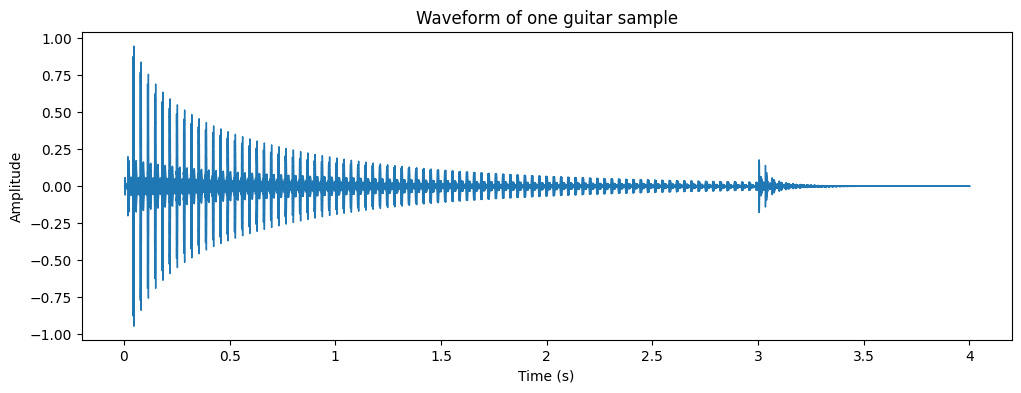

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os


# Find a guitar instrument folder from the created mini_nsynth structure
guitar_instrument_folder = None
for instrument_name in os.listdir("mini_nsynth"):
    if instrument_name.startswith("guitar"):
        guitar_instrument_folder = instrument_name
        break

if guitar_instrument_folder is None:
    raise ValueError("No guitar instrument folders found in mini_nsynth!")

# Pick one audio file (example: first guitar file)
audio_path_prefix = os.path.join("mini_nsynth", guitar_instrument_folder)
audio_file = os.path.join(audio_path_prefix, os.listdir(audio_path_prefix)[0])

# Load audio
y, sr = librosa.load(audio_file, sr=None)  # sr=None keeps original 16kHz

# Print basic info
print("File:", audio_file)
print("Sampling rate:", sr)
print("Waveform shape:", y.shape)
print("Duration (seconds):", len(y)/sr)

# Visualize waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of one guitar sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Trimming the silence

In [21]:
import librosa.effects

y_trimmed, index = librosa.effects.trim(y, top_db=20)

print("Original waveform length:", len(y))
print("Trimmed waveform length:", len(y_trimmed))

Original waveform length: 64000
Trimmed waveform length: 49664


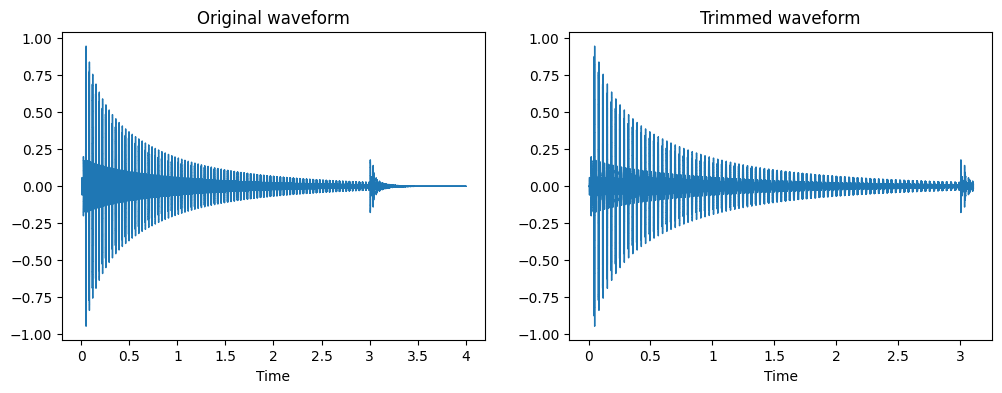

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Original waveform")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed waveform")
plt.show()

# Normalizing Amplitude

In [23]:
import numpy as np
max_val=np.max(np.abs(y_trimmed))
if max_val>0:
  y_normalized=y_trimmed/max_val
else:
  y_normalized=y_trimmed


print("Max amplitude before:", np.max(np.abs(y_trimmed)))
print("Max amplitude after:", np.max(np.abs(y_normalized)))

Max amplitude before: 0.94503784
Max amplitude after: 1.0


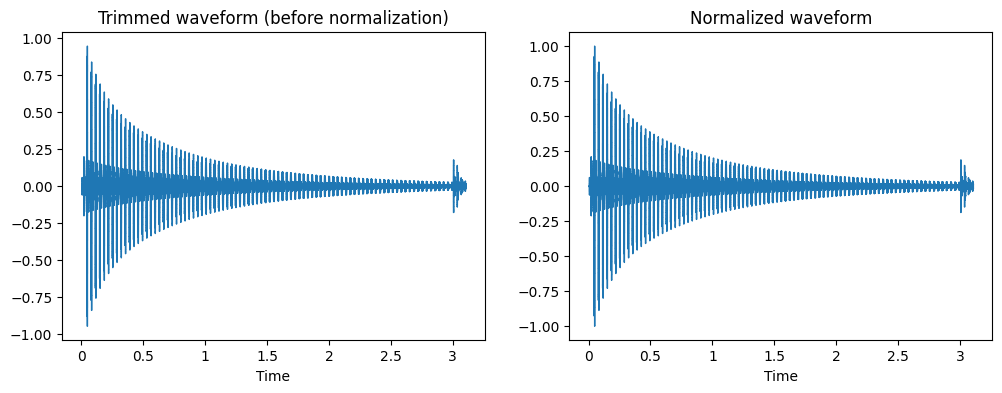

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed waveform (before normalization)")
plt.subplot(1, 2, 2)
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Normalized waveform")
plt.show()

# STFT

In [25]:
D = librosa.stft(y_normalized, n_fft=1024, hop_length=512)

print("STFT shape:", D.shape)

STFT shape: (513, 98)


# Mel Scale

In [26]:
mel_spec = librosa.feature.melspectrogram(
    y=y_normalized,
    sr=sr,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

print("Mel Spectrogram shape:", mel_spec.shape)

Mel Spectrogram shape: (128, 98)


# Log Scale

In [27]:
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Log Mel shape:", mel_spec_db.shape)
print("Min value:", mel_spec_db.min())
print("Max value:", mel_spec_db.max())

Log Mel shape: (128, 98)
Min value: -80.0
Max value: 0.0


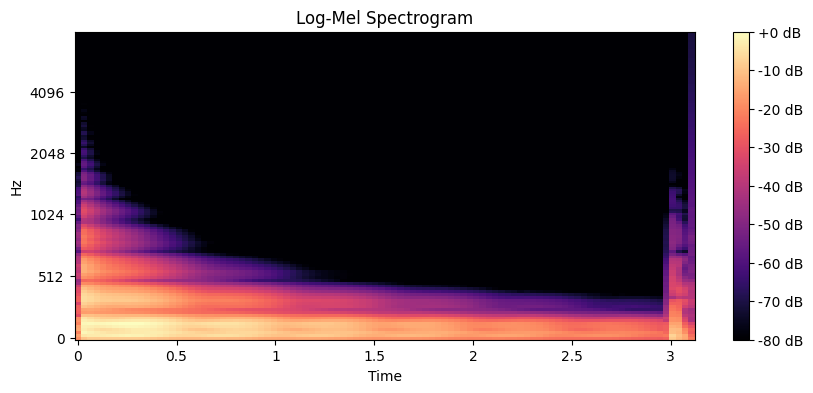

In [28]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram")
plt.show()

In [29]:
mfcc = librosa.feature.mfcc(
    y=y_normalized,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 98)


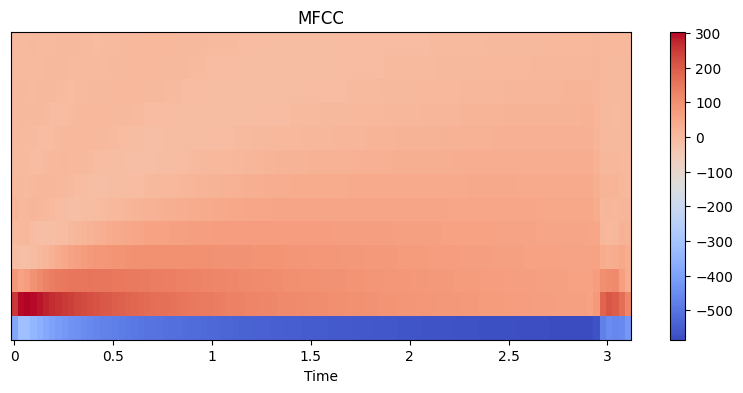

In [30]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=sr
)
plt.colorbar()
plt.title("MFCC")
plt.show()

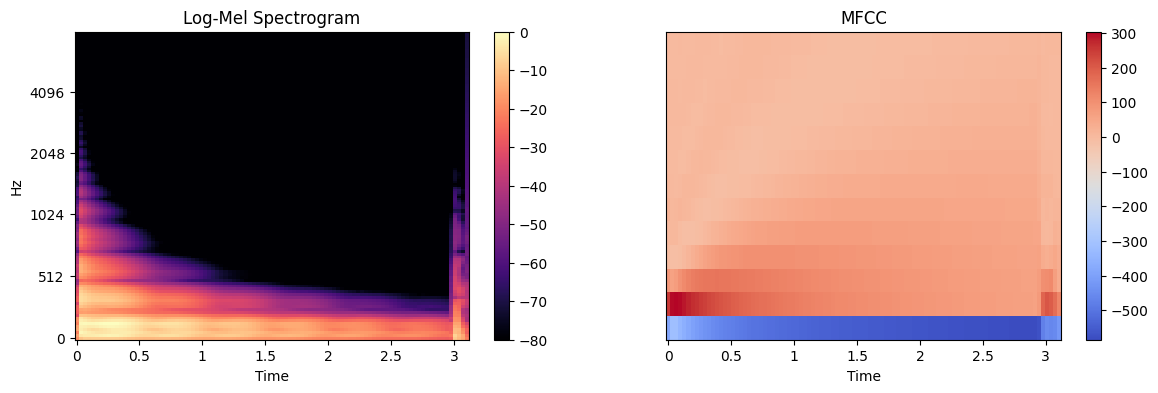

In [31]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.title("Log-Mel Spectrogram")
plt.colorbar()

plt.subplot(1,2,2)
librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis='time'
)
plt.title("MFCC")
plt.colorbar()

plt.show()

**Observation**
# Shape Difference

Log-Mel Spectrogram shape: (128, T)

MFCC shape: (13, T)

# Visual Difference

The Log-Mel Spectrogram shows detailed frequency patterns across time. Harmonic structures and energy distributions across Mel bands are clearly visible.

The MFCC representation appears smoother and less detailed. Fine harmonic patterns are no longer visible.

In [32]:
import os
import librosa
import numpy as np

X = []
y = []

base_path = "mini_nsynth"

for instrument in os.listdir(base_path):

    instrument_path = os.path.join(base_path, instrument)

    for file in os.listdir(instrument_path):

        file_path = os.path.join(instrument_path, file)

        # Load audio
        signal, sr = librosa.load(file_path, sr=16000)

        # Normalize
        max_val=np.max(np.abs(signal))
        if max_val>0:
          signal=signal/max_val
        max_len=16000
        if len(signal)>max_len:
          signal=signal[:max_len]
        else:
          signal=np.pad(signal,(0,max_len-len(signal)))

        # Create Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )

        # Convert to Log scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Append to dataset
        X.append(mel_spec_db)
        y.append(instrument)

In [33]:
# Create label map automatically
instrument_list = sorted(list(set(y)))

label_map = {instrument: idx for idx, instrument in enumerate(instrument_list)}

print("Label Map:", label_map)

# Convert to numbers
y = np.array([label_map[instrument] for instrument in y])

Label Map: {'bass_electronic_018': 0, 'bass_electronic_025': 1, 'bass_electronic_027': 2, 'bass_synthetic_009': 3, 'bass_synthetic_033': 4, 'bass_synthetic_034': 5, 'bass_synthetic_068': 6, 'bass_synthetic_098': 7, 'bass_synthetic_134': 8, 'bass_synthetic_135': 9, 'flute_acoustic_002': 10, 'flute_synthetic_000': 11, 'guitar_acoustic_010': 12, 'guitar_acoustic_014': 13, 'guitar_acoustic_015': 14, 'guitar_acoustic_021': 15, 'guitar_acoustic_030': 16, 'guitar_electronic_022': 17, 'guitar_electronic_028': 18, 'keyboard_acoustic_004': 19, 'keyboard_electronic_001': 20, 'keyboard_electronic_002': 21, 'keyboard_electronic_003': 22, 'keyboard_electronic_069': 23, 'keyboard_electronic_078': 24, 'keyboard_electronic_098': 25, 'keyboard_synthetic_000': 26, 'string_acoustic_012': 27, 'string_acoustic_014': 28, 'string_acoustic_056': 29, 'string_acoustic_057': 30, 'string_acoustic_071': 31, 'string_acoustic_080': 32}


In [34]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1621, 128, 32)
y shape: (1621,)


In [35]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (1621, 128, 32, 1)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1296, 128, 32, 1)
X_val shape: (325, 128, 32, 1)


In [37]:
from tensorflow.keras.utils import to_categorical

num_classes = len(instrument_list)

y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

y_train shape: (1296, 33)
y_val shape: (325, 33)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output layer (VERY IMPORTANT)
model.add(Dense(len(instrument_list), activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 30, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 30, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 758,689 (2.89 MB)

 Trainable params: 758,497 (2.89 MB)

 Non-trainable params: 192 (768.00 B)

In [39]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.0679 - loss: 3.7718 - val_accuracy: 0.0369 - val_loss: 5.5779
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.1265 - loss: 3.2353 - val_accuracy: 0.1108 - val_loss: 3.2108
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.1605 - loss: 3.1073 - val_accuracy: 0.1477 - val_loss: 3.0567
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.1821 - loss: 2.9836 - val_accuracy: 0.1477 - val_loss: 3.7774
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.2083 - loss: 2.9367 - val_accuracy: 0.1754 - val_loss: 3.3852
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2122 - loss: 2.8528 - val_accuracy: 0.1046 - val_loss: 3.4018
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.2330 - loss: 2.6845 - val_accuracy: 0.2708 - val_loss: 2.6356
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.2492 - loss: 2.6825 - val_accuracy: 0.2862 

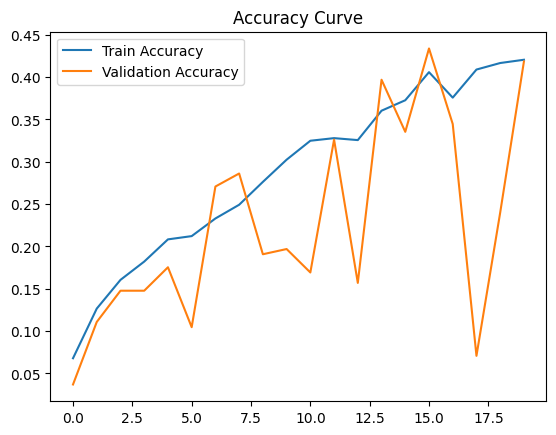

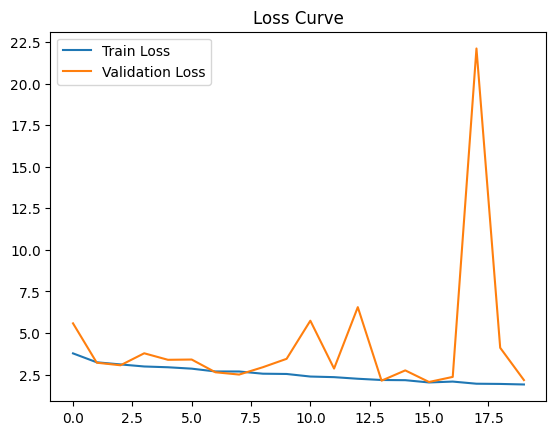

In [41]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [42]:
from sklearn.metrics import classification_report
import numpy as np

# Predict on validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot y_val back to integer
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred, target_names=instrument_list))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
                         precision    recall  f1-score   support

    bass_electronic_018       0.21      1.00      0.34        10
    bass_electronic_025       0.00      0.00      0.00        10
    bass_electronic_027       0.25      0.20      0.22        10
     bass_synthetic_009       0.35      0.70      0.47        10
     bass_synthetic_033       0.75      0.60      0.67        10
     bass_synthetic_034       1.00      1.00      1.00        10
     bass_synthetic_068       0.19      0.30      0.23        10
     bass_synthetic_098       0.80      0.80      0.80        10
     bass_synthetic_134       0.91      1.00      0.95        10
     bass_synthetic_135       0.56      0.90      0.69        10
     flute_acoustic_002       1.00      0.20      0.33        10
    flute_synthetic_000       1.00      0.10      0.18        10
    guitar_acoustic_010       0.67      0.40      0.50        10
    guitar_acoustic_014       0.22      0.40     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=instrument_list,
    output_dict=True
)

# Find weakest class (lowest F1-score)
weakest_class = min(
    instrument_list,
    key=lambda x: report[x]['f1-score']
)

print("Weakest class:", weakest_class)
print("F1-score:", report[weakest_class]['f1-score'])

Weakest class: bass_electronic_025
F1-score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
print("\nSome prediction errors:\n")

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        print("Actual:", instrument_list[y_true[i]])
        print("Predicted:", instrument_list[y_pred[i]])
        print("-----")

    # Show only first 10 errors
    if i > 10:
        break


Some prediction errors:

Actual: guitar_acoustic_014
Predicted: keyboard_electronic_098
-----
Actual: keyboard_electronic_098
Predicted: guitar_electronic_022
-----
Actual: string_acoustic_057
Predicted: bass_synthetic_009
-----


In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [47]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,   # we allow more, early stopping will stop automatically
    batch_size=16,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4367 - loss: 1.8043

81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.4298 - loss: 1.8674 - val_accuracy: 0.3631 - val_loss: 2.4784 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4308 - loss: 1.9349

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.4313 - loss: 1.8585 - val_accuracy: 0.5292 - val_loss: 1.7169 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4468 - loss: 1.7694 - val_accuracy: 0.3508 - val_loss: 3.0879 - learning_rate: 0.0010
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4772 - loss: 1.6840

81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.4568 - loss: 1.7411 - val_accuracy: 0.5323 - val_loss: 1.5068 - learning_rate: 0.0010
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.4637 - loss: 1.7281 - val_accuracy: 0.5262 - val_loss: 1.5807 - learning_rate: 0.0010
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4739 - loss: 1.6733
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4699 - loss: 1.6900 - val_accuracy: 0.5600 - val_loss: 1.6684 - learning_rate: 0.0010
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4669 - loss: 1.6976

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.4738 - loss: 1.6459 - val_accuracy: 0.6031 - val_loss: 1.3593 - learning_rate: 5.0000e-04
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5183 - loss: 1.5008

...

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.5424 - loss: 1.4187 - val_accuracy: 0.6831 - val_loss: 1.0225 - learning_rate: 2.5000e-04
Epoch 12/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.5656 - loss: 1.3292 - val_accuracy: 0.6985 - val_loss: 1.0278 - learning_rate: 2.5000e-04
Epoch 13/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5389 - loss: 1.3442

81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.5540 - loss: 1.3405 - val_accuracy: 0.7262 - val_loss: 1.0109 - learning_rate: 2.5000e-04
Epoch 14/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5488 - loss: 1.4010

81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.5602 - loss: 1.3073 - val_accuracy: 0.7046 - val_loss: 0.9893 - learning_rate: 2.5000e-04
Epoch 15/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.5833 - loss: 1.2308 - val_accuracy: 0.7138 - val_loss: 1.0303 - learning_rate: 2.5000e-04
Epoch 16/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5774 - loss: 1.2527
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5856 - loss: 1.2502 - val_accuracy: 0.7015 - val_loss: 1.0995 - learning_rate: 2.5000e-04
Epoch 17/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5705 - loss: 1.2527

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5849 - loss: 1.2325 - val_accuracy: 0.7385 - val_loss: 0.9076 - learning_rate: 1.2500e-04
Epoch 18/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.5941 - loss: 1.2229 - val_accuracy: 0.7354 - val_loss: 0.9928 - learning_rate: 1.2500e-04
Epoch 19/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5921 - loss: 1.2128

81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.5988 - loss: 1.2083 - val_accuracy: 0.7538 - val_loss: 0.9058 - learning_rate: 1.2500e-04
Epoch 20/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.5856 - loss: 1.2176 - val_accuracy: 0.7477 - val_loss: 0.9076 - learning_rate: 1.2500e-04


In [48]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=instrument_list
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
                         precision    recall  f1-score   support

    bass_electronic_018       0.62      1.00      0.77        10
    bass_electronic_025       1.00      0.90      0.95        10
    bass_electronic_027       0.82      0.90      0.86        10
     bass_synthetic_009       1.00      1.00      1.00        10
     bass_synthetic_033       0.77      1.00      0.87        10
     bass_synthetic_034       1.00      1.00      1.00        10
     bass_synthetic_068       0.88      0.70      0.78        10
     bass_synthetic_098       1.00      1.00      1.00        10
     bass_synthetic_134       1.00      1.00      1.00        10
     bass_synthetic_135       0.91      1.00      0.95        10
     flute_acoustic_002       1.00      1.00      1.00        10
    flute_synthetic_000       1.00      1.00      1.00        10
    guitar_acoustic_010       0.88      0.70      0.78        10
    guitar_acoustic_014       0.36      0.80     

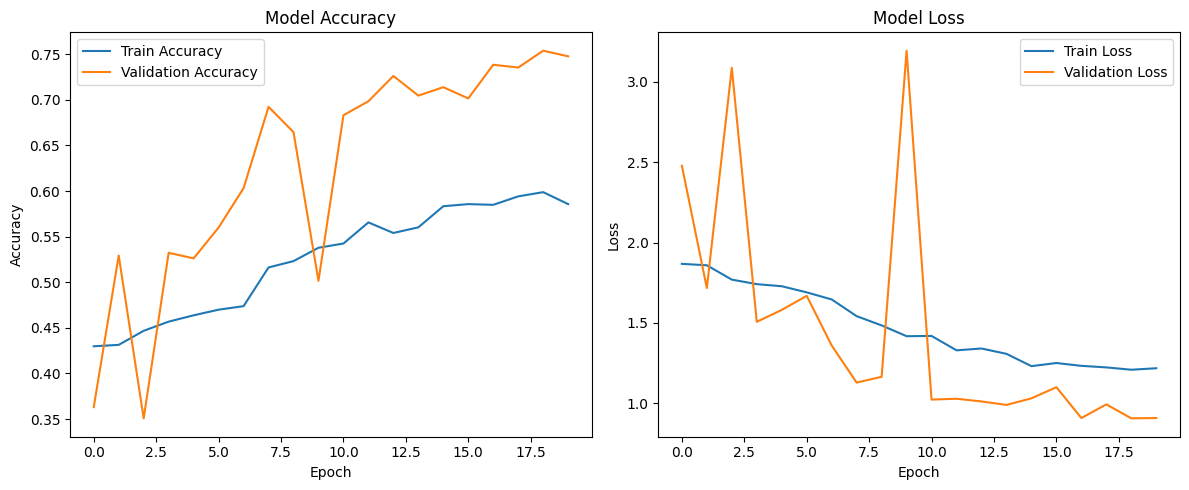

In [49]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**The model shows consistent improvement in both training and validation accuracy. Validation accuracy is slightly higher than training accuracy, indicating good generalization and effective regularization. The loss curves decrease steadily without divergence, suggesting the model is not overfitting and is learning meaningful patterns from the data.**

# Batch Normalization

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [51]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:])) # Corrected input_shape
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Dropout BEFORE dense layer
model.add(Dropout(0.5))

# Dense layer
model.add(Dense(64, activation='relu'))

# Output layer (corrected to num_classes)
model.add(Dense(num_classes, activation='softmax')) # num_classes is 33

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 30, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 30, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 758,689 (2.89 MB)

 Trainable params: 758,497 (2.89 MB)

 Non-trainable params: 192 (768.00 B)

In [52]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.2269 - loss: 3.1776 - val_accuracy: 0.0462 - val_loss: 10.2384
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.5031 - loss: 1.7004 - val_accuracy: 0.0769 - val_loss: 6.2505
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.6597 - loss: 0.9987 - val_accuracy: 0.1969 - val_loss: 4.7551
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.7886 - loss: 0.6196 - val_accuracy: 0.4308 - val_loss: 2.1615
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 284ms/step - accuracy: 0.8696 - loss: 0.4043 - val_accuracy: 0.4185 - val_loss: 2.1261
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.9035 - loss: 0.2970 - val_accuracy: 0.5292 - val_loss: 1.4004
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.9244 - loss: 0.2294 - val_accuracy: 0.6862 - val_loss: 0.9661
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.9406 - loss: 0.1720 - val_accuracy:

In [54]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=instrument_list
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
                         precision    recall  f1-score   support

    bass_electronic_018       1.00      0.70      0.82        10
    bass_electronic_025       0.50      0.10      0.17        10
    bass_electronic_027       0.50      0.80      0.62        10
     bass_synthetic_009       1.00      0.80      0.89        10
     bass_synthetic_033       1.00      0.70      0.82        10
     bass_synthetic_034       1.00      1.00      1.00        10
     bass_synthetic_068       1.00      0.30      0.46        10
     bass_synthetic_098       1.00      0.60      0.75        10
     bass_synthetic_134       0.00      0.00      0.00        10
     bass_synthetic_135       0.54      0.70      0.61        10
     flute_acoustic_002       0.62      1.00      0.77        10
    flute_synthetic_000       0.19      1.00      0.32        10
    guitar_acoustic_010       0.33      0.80      0.47        10
    guitar_acoustic_014       1.00      0.50     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**The dataset used contains only one instrument per audio sample. Therefore, it is inherently a single-label classification problem. While a sigmoid activation with binary crossentropy is suitable for multi-label classification, it is not appropriate here. Hence, the softmax activation with categorical crossentropy provides better and correct results.**

In [55]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.8827 - loss: 0.4597 - val_accuracy: 0.0523 - val_loss: 66.9414
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7770 - loss: 0.9388 - val_accuracy: 0.1692 - val_loss: 12.9041
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.8511 - loss: 0.5927 - val_accuracy: 0.4154 - val_loss: 5.0800
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.9267 - loss: 0.2963 - val_accuracy: 0.5231 - val_loss: 3.2339
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9336 - loss: 0.2805 - val_accuracy: 0.3692 - val_loss: 3.9385
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9545 - loss: 0.1435 - val_accuracy: 0.6062 - val_loss: 2.1685
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9498 - loss: 0.1668 - val_accuracy: 0.7538 - val_loss: 1.0521
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9715 - loss: 0.0838 - val_accuracy: 0.5969

In [56]:
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Validation Accuracy: 0.6000000238418579


# Changing Batch Size

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(instrument_list), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_bs32 = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=32   # changed
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.2037 - loss: 3.2876 - val_accuracy: 0.0369 - val_loss: 18.7758
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.4537 - loss: 1.9086 - val_accuracy: 0.0862 - val_loss: 9.4185
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.6343 - loss: 1.2590 - val_accuracy: 0.1938 - val_loss: 6.6692
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.7469 - loss: 0.8160 - val_accuracy: 0.2062 - val_loss: 4.7909
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.8133 - loss: 0.6052 - val_accuracy: 0.2985 - val_loss: 4.5026
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.8657 - loss: 0.3963 - val_accuracy: 0.4062 - val_loss: 2.4853
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.8773 - loss: 0.3816 - val_accuracy: 0.4400 - val_loss: 2.1536
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.9259 - loss: 0.2362 - val_accurac

In [59]:
print("Batch Size 32 - Val Accuracy:", history_bs32.history['val_accuracy'][-1])

Batch Size 32 - Val Accuracy: 0.6399999856948853


**Increasing batch size from 16 to 32 slightly reduced validation accuracy, indicating that smaller batch sizes help the model learn more effectively for this dataset.**

# Changing Drouput

In [60]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dropout(0.3))   #  changed from 0.5
model.add(Dense(64, activation='relu'))
model.add(Dense(len(instrument_list), activation='softmax'))

In [61]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
history_dropout = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.2708 - loss: 3.0192 - val_accuracy: 0.0800 - val_loss: 7.0220
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.6073 - loss: 1.3459 - val_accuracy: 0.2985 - val_loss: 3.4613
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.7562 - loss: 0.7813 - val_accuracy: 0.6554 - val_loss: 1.1408
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.8642 - loss: 0.4141 - val_accuracy: 0.7138 - val_loss: 0.9416
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9043 - loss: 0.2849 - val_accuracy: 0.5292 - val_loss: 2.0304
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9190 - loss: 0.2704 - val_accuracy: 0.7508 - val_loss: 0.8392
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9290 - loss: 0.1891 - val_accuracy: 0.5046 - val_loss: 2.3628
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9614 - loss: 0.1298 - val_accuracy: 0.7477 

In [63]:
print("Dropout 0.3 - Val Accuracy:", history_dropout.history['val_accuracy'][-1])

Dropout 0.3 - Val Accuracy: 0.563076913356781


**Reducing dropout from 0.5 to 0.3 significantly decreased validation accuracy, indicating overfitting. This shows that higher dropout is necessary to regularize the model effectively.**

# Changing Filters

In [64]:
model = Sequential()

model.add(Conv2D(64, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dropout(0.5))   # same as base
model.add(Dense(64, activation='relu'))
model.add(Dense(len(instrument_list), activation='softmax'))

In [65]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [66]:
history_filters = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.1898 - loss: 3.5408 - val_accuracy: 0.0646 - val_loss: 7.2294
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 227ms/step - accuracy: 0.3904 - loss: 2.2898 - val_accuracy: 0.2769 - val_loss: 2.7116
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.5170 - loss: 1.7263 - val_accuracy: 0.2123 - val_loss: 4.3214
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 0.6296 - loss: 1.2509 - val_accuracy: 0.2092 - val_loss: 6.3449
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 223ms/step - accuracy: 0.6875 - loss: 1.0147 - val_accuracy: 0.1477 - val_loss: 8.7417
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.7685 - loss: 0.7686 - val_accuracy: 0.2523 - val_loss: 3.9735
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.7978 - loss: 0.6506 - val_accuracy: 0.1754 - val_loss: 8.3014
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.8048 - loss: 0.6076 - val_accu

In [67]:
print("Filters 64-128 - Val Accuracy:", history_filters.history['val_accuracy'][-1])

Filters 64-128 - Val Accuracy: 0.3199999928474426


**Increasing filters from (32, 64) to (64, 128) reduced validation accuracy due to overfitting, indicating that a simpler model works better for this dataset.**

# Changing Learning Rate

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(instrument_list), activation='softmax'))

In [69]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

In [70]:
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
history_lr = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2515 - loss: 3.0427 - val_accuracy: 0.0738 - val_loss: 5.4272
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5231 - loss: 1.6362 - val_accuracy: 0.2092 - val_loss: 3.9498
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.7153 - loss: 0.9627 - val_accuracy: 0.4123 - val_loss: 2.0620
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.8187 - loss: 0.5937 - val_accuracy: 0.6585 - val_loss: 1.1118
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.8835 - loss: 0.3884 - val_accuracy: 0.6800 - val_loss: 1.0760
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9051 - loss: 0.2719 - val_accuracy: 0.6277 - val_loss: 1.2748
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9367 - loss: 0.2164 - val_accuracy: 0.6462 - val_loss: 1.2979
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9506 - loss: 0.1568 - val_accuracy: 0.6369 

In [72]:
print("LR 0.0005 - Val Accuracy:", history_lr.history['val_accuracy'][-1])

LR 0.0005 - Val Accuracy: 0.5292307734489441


# Changing Optimizers

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def create_model():
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(len(instrument_list), activation='softmax'))

    return model

# SGD

In [74]:
from tensorflow.keras.optimizers import SGD

model_sgd = create_model()

model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.2022 - loss: 3.1528 - val_accuracy: 0.0615 - val_loss: 5.2580
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.4352 - loss: 1.9579 - val_accuracy: 0.1692 - val_loss: 3.7193
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.5895 - loss: 1.3168 - val_accuracy: 0.3846 - val_loss: 2.3702
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7091 - loss: 0.9014 - val_accuracy: 0.5415 - val_loss: 1.5106
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.7454 - loss: 0.7438 - val_accuracy: 0.4000 - val_loss: 1.9140
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.8048 - loss: 0.5924 - val_accuracy: 0.7108 - val_loss: 0.8907
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8248 - loss: 0.5113 - val_accuracy: 0.3815 - val_loss: 2.4800
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.8588 - loss: 0.4010 - val_accuracy: 0.6277 - 

In [76]:
print("SGD Val Accuracy:", history_sgd.history['val_accuracy'][-1])
print("SGD Val Loss:", history_sgd.history['val_loss'][-1])

SGD Val Accuracy: 0.8153846263885498
SGD Val Loss: 0.5782990455627441


**SGD showed lower accuracy and higher loss, indicating slower convergence and less efficient learning.**

# RMSprop

In [77]:
model_rms = create_model()
from tensorflow.keras.optimizers import RMSprop

model_rms.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
history_rms = model_rms.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.2307 - loss: 3.3336 - val_accuracy: 0.1692 - val_loss: 3.0034
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5162 - loss: 1.7503 - val_accuracy: 0.4369 - val_loss: 2.1843
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.6906 - loss: 1.0957 - val_accuracy: 0.3169 - val_loss: 3.5658
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.7731 - loss: 0.6943 - val_accuracy: 0.5323 - val_loss: 2.1039
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.8341 - loss: 0.5349 - val_accuracy: 0.5262 - val_loss: 2.5774
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.8711 - loss: 0.4116 - val_accuracy: 0.1508 - val_loss: 13.8281
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9074 - loss: 0.3489 - val_accuracy: 0.6369 - val_loss: 1.6044
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9082 - loss: 0.3216 - val_accuracy: 

In [79]:
print("RMSprop Val Accuracy:", history_rms.history['val_accuracy'][-1])
print("RMSprop Val Loss:", history_rms.history['val_loss'][-1])

RMSprop Val Accuracy: 0.4276922941207886
RMSprop Val Loss: 6.834407329559326


**RMSprop slightly improved accuracy compared to SGD but resulted in higher validation loss, indicating unstable learning and less confident predictions.**

# Adam

In [80]:
model_adam = create_model()
from tensorflow.keras.optimizers import Adam

model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.2284 - loss: 3.1087 - val_accuracy: 0.0615 - val_loss: 5.6860
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.4977 - loss: 1.8528 - val_accuracy: 0.3723 - val_loss: 2.1018
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.6535 - loss: 1.2061 - val_accuracy: 0.3169 - val_loss: 3.6295
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.7523 - loss: 0.7882 - val_accuracy: 0.5538 - val_loss: 1.4491
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8187 - loss: 0.5877 - val_accuracy: 0.3662 - val_loss: 3.0497
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.8750 - loss: 0.3912 - val_accuracy: 0.5415 - val_loss: 1.8916
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9020 - loss: 0.3053 - val_accuracy: 0.6708 - val_loss: 1.2767
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9113 - loss: 0.2625 - val_accuracy: 0.5815 

In [82]:
print("Adam Val Accuracy:", history_adam.history['val_accuracy'][-1])
print("Adam Val Loss:", history_adam.history['val_loss'][-1])

Adam Val Accuracy: 0.8061538338661194
Adam Val Loss: 0.846410870552063


In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

def create_regularized_model(dropout_rate):

    model = Sequential()

    # Conv Block 1
    model.add(Conv2D(32, (3,3), activation='relu',
                     kernel_regularizer=l2(0.001),
                     input_shape=X_train.shape[1:]))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Conv Block 2
    model.add(Conv2D(64, (3,3), activation='relu',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    # Flatten
    model.add(Flatten())

    # Dense + L2
    model.add(Dense(64, activation='relu',
                    kernel_regularizer=l2(0.001)))

    #  Dropout AFTER Dense (as asked)
    model.add(Dropout(dropout_rate))

    # Output
    model.add(Dense(len(instrument_list), activation='softmax'))

    return model

In [84]:
model_d03 = create_regularized_model(0.3)

model_d03.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_d03 = model_d03.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

print("Dropout 0.3 Accuracy:", history_d03.history['val_accuracy'][-1])
print("Dropout 0.3 Loss:", history_d03.history['val_loss'][-1])

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.1273 - loss: 3.7846 - val_accuracy: 0.0462 - val_loss: 7.8861
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.2377 - loss: 2.9083 - val_accuracy: 0.1138 - val_loss: 5.5459
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.3719 - loss: 2.4472 - val_accuracy: 0.2154 - val_loss: 3.6542
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.4483 - loss: 2.1241 - val_accuracy: 0.0892 - val_loss: 11.4607
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.5069 - loss: 1.9244 - val_accuracy: 0.3446 - val_loss: 2.7717
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.5417 - loss: 1.7077 - val_accuracy: 0.2923 - val_loss: 3.8413
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.6242 - loss: 1.3928 - val_accuracy: 0.7077 - val_loss: 1.2894
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.6481 - loss: 1.4110 - val_accuracy: 0.550

In [85]:
model_d05 = create_regularized_model(0.5)

model_d05.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_d05 = model_d05.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=16
)

print("Dropout 0.5 Accuracy:", history_d05.history['val_accuracy'][-1])
print("Dropout 0.5 Loss:", history_d05.history['val_loss'][-1])

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.0756 - loss: 4.0538 - val_accuracy: 0.0646 - val_loss: 5.2658
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.1381 - loss: 3.4539 - val_accuracy: 0.1200 - val_loss: 3.4993
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.1705 - loss: 3.2735 - val_accuracy: 0.1569 - val_loss: 3.2374
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.2060 - loss: 3.1102 - val_accuracy: 0.2615 - val_loss: 2.9179
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.2407 - loss: 3.0726 - val_accuracy: 0.1415 - val_loss: 3.5659
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.2330 - loss: 2.9875 - val_accuracy: 0.0338 - val_loss: 10.9050
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.2685 - loss: 2.8528 - val_accuracy: 0.2185 - val_loss: 3.3742
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.3125 - loss: 2.7089 - val_accuracy: 0.

In [86]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)

for i in range(len(unique)):
    print(instrument_list[unique[i]], ":", counts[i])


print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

bass_electronic_018 : 50
bass_electronic_025 : 50
bass_electronic_027 : 50
bass_synthetic_009 : 50
bass_synthetic_033 : 50
bass_synthetic_034 : 50
bass_synthetic_068 : 50
bass_synthetic_098 : 50
bass_synthetic_134 : 50
bass_synthetic_135 : 50
flute_acoustic_002 : 50
flute_synthetic_000 : 50
guitar_acoustic_010 : 50
guitar_acoustic_014 : 50
guitar_acoustic_015 : 50
guitar_acoustic_021 : 50
guitar_acoustic_030 : 41
guitar_electronic_022 : 50
guitar_electronic_028 : 50
keyboard_acoustic_004 : 50
keyboard_electronic_001 : 50
keyboard_electronic_002 : 50
keyboard_electronic_003 : 50
keyboard_electronic_069 : 50
keyboard_electronic_078 : 50
keyboard_electronic_098 : 50
keyboard_synthetic_000 : 50
string_acoustic_012 : 46
string_acoustic_014 : 50
string_acoustic_056 : 50
string_acoustic_057 : 50
string_acoustic_071 : 43
string_acoustic_080 : 41
Train samples: 1296
Validation samples: 325


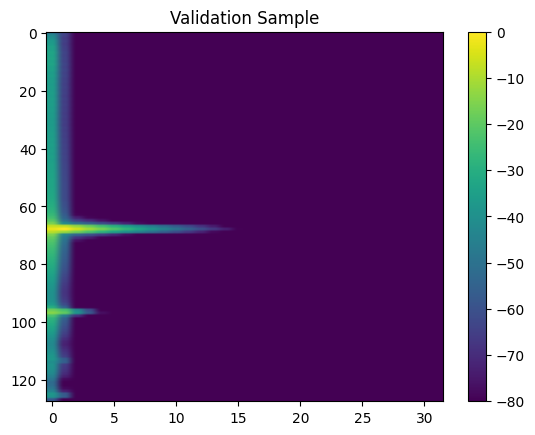

Label: guitar_acoustic_014


In [87]:
import matplotlib.pyplot as plt

plt.imshow(X_val[0].squeeze(), aspect='auto')
plt.title("Validation Sample")
plt.colorbar()
plt.show()

print("Label:", instrument_list[np.argmax(y_val[0])])

In [88]:
val_loss, val_acc = model_d05.evaluate(X_val, y_val)

print("Final Validation Accuracy:", val_acc)
print("Final Validation Loss:", val_loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5600 - loss: 1.6274
Final Validation Accuracy: 0.5600000023841858
Final Validation Loss: 1.6273937225341797


In [89]:
import os
import numpy as np
import librosa

# Find a guitar instrument folder from the created mini_nsynth structure
guitar_instrument_folder = None
for instrument_name in os.listdir("mini_nsynth"):
    if instrument_name.startswith("guitar"):
        guitar_instrument_folder = instrument_name
        break

if guitar_instrument_folder is None:
    raise ValueError("No guitar instrument folders found in mini_nsynth!")

# Construct the correct path to the guitar instrument folder
guitar_folder_path = os.path.join("mini_nsynth", guitar_instrument_folder)

files = os.listdir(guitar_folder_path)[:5]

full_signal = []

for f in files:
    signal, sr = librosa.load(os.path.join(guitar_folder_path, f), sr=16000)
    full_signal.extend(signal)

signal = np.array(full_signal)

print("Total length:", len(signal))
print("Duration:", len(signal)/sr)

Total length: 320000
Duration: 20.0


In [90]:
segment_duration = 1  # seconds
samples_per_segment = sr * segment_duration

print("Samples per segment:", samples_per_segment)

Samples per segment: 16000


In [91]:
num_segments = len(signal) // samples_per_segment

print("Number of segments:", num_segments)

Number of segments: 20


In [92]:
segments = []

for i in range(num_segments):
    start = i * samples_per_segment
    end = start + samples_per_segment

    segment = signal[start:end]
    segments.append(segment)

In [93]:
print("Total segments:", len(segments))
print("Shape of one segment:", segments[0].shape)

Total segments: 20
Shape of one segment: (16000,)


In [94]:
import numpy as np

X_segments = []

for segment in segments:

    # Normalize
    max_val = np.max(np.abs(segment))
    if max_val > 0:
        segment = segment / max_val

    # Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    X_segments.append(mel_spec_db)

In [95]:
X_segments = np.array(X_segments)
X_segments = X_segments[..., np.newaxis]

print("Final shape:", X_segments.shape)

Final shape: (20, 128, 32, 1)


In [96]:
predictions = model.predict(X_segments)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
(20, 33)


In [97]:
import numpy as np

raw_preds = np.argmax(predictions, axis=1)
print("Raw predictions:", raw_preds)

Raw predictions: [18 21 25  8 18 18 18 16 18  9  9  9 18 14 14  9 18 21 17 16]


In [98]:
avg_prediction = np.mean(predictions, axis=0)

print("Average prediction:", avg_prediction)

Average prediction: [6.7989335e-05 1.5681377e-05 3.4620090e-08 4.0222611e-03 7.2200599e-08
 1.5961046e-05 2.6175790e-03 1.1963101e-06 2.7882818e-02 1.6922364e-01
 2.0485941e-06 9.2874433e-07 5.2108290e-03 2.7004401e-06 1.1548151e-01
 2.0387978e-04 9.6820906e-02 4.4089273e-02 3.3598304e-01 1.1749808e-04
 2.6988317e-04 1.2306021e-01 1.5152299e-08 2.6785498e-02 6.6150632e-04
 4.6558745e-02 8.4480492e-04 2.8307448e-07 3.8253940e-05 2.5439892e-06
 1.0794317e-06 6.0685451e-08 1.7277478e-05]


In [99]:
print("predictions shape:", predictions.shape)
print("avg_prediction shape:", avg_prediction.shape)

predictions shape: (20, 33)
avg_prediction shape: (33,)


In [100]:
threshold = 0.1

final_labels = (avg_prediction > threshold).astype(int)

print("Thresholded output:", final_labels)

Thresholded output: [0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [101]:
smoothed_preds = []
window = 3

for i in range(len(predictions)):
    start = max(0, i - window)
    end = min(len(predictions), i + window)

    avg = np.mean(predictions[start:end], axis=0)
    smoothed_preds.append(avg)

smoothed_preds = np.array(smoothed_preds)

In [102]:
smooth_labels = np.argmax(smoothed_preds, axis=1)

print("Raw:", raw_preds)
print("Smoothed:", smooth_labels)

Raw: [18 21 25  8 18 18 18 16 18  9  9  9 18 14 14  9 18 21 17 16]
Smoothed: [18 18 18 18 18 18 18 18 18  9  9  9  9  9  9 14 14 21 21 21]


In [104]:
instruments = set()

for key in metadata:
    instruments.add(metadata[key]['instrument_str'])

In [105]:
instrument_list = sorted(list(instruments))

print(len(instrument_list))  # should be 33

53


In [106]:
# Create correct instrument list
instrument_list = sorted(list(instruments))

print("Final Instruments:")

for i in range(len(avg_prediction)):
    if final_labels[i] == 1:
        print(instrument_list[i])

# Top prediction
top_index = np.argmax(avg_prediction)
print("\nTop instrument:", instrument_list[top_index])

Final Instruments:
bass_synthetic_135
brass_acoustic_059
guitar_acoustic_014
guitar_acoustic_030

Top instrument: guitar_acoustic_014


In [107]:
print(predictions.shape)
print(avg_prediction.shape)
print(final_labels)

(20, 33)
(33,)
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
